In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'font.size'        : 12,
})
print('All imports OK ✓')

All imports OK ✓


In [4]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer_data = load_breast_cancer()

df = pd.DataFrame(cancer_data.data, columns=cancer_data.feature_names)

df['target'] = cancer_data.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

In [5]:
load_breast_cancer().feature_names


array(['mean radius', 'mean texture', 'mean perimeter', 'mean area',
       'mean smoothness', 'mean compactness', 'mean concavity',
       'mean concave points', 'mean symmetry', 'mean fractal dimension',
       'radius error', 'texture error', 'perimeter error', 'area error',
       'smoothness error', 'compactness error', 'concavity error',
       'concave points error', 'symmetry error',
       'fractal dimension error', 'worst radius', 'worst texture',
       'worst perimeter', 'worst area', 'worst smoothness',
       'worst compactness', 'worst concavity', 'worst concave points',
       'worst symmetry', 'worst fractal dimension'], dtype='<U23')

In [6]:
print('=== Shape ===')
print(df.shape)

print('\n=== Data types ===')
print(df.dtypes)

print('\n=== Missing values per column ===')
print(df.isnull().sum())

print('\n=== Summary statistics ===')
df.describe().round(3)

=== Shape ===
(569, 31)

=== Data types ===
mean radius                float64
mean texture               float64
mean perimeter             float64
mean area                  float64
mean smoothness            float64
mean compactness           float64
mean concavity             float64
mean concave points        float64
mean symmetry              float64
mean fractal dimension     float64
radius error               float64
texture error              float64
perimeter error            float64
area error                 float64
smoothness error           float64
compactness error          float64
concavity error            float64
concave points error       float64
symmetry error             float64
fractal dimension error    float64
worst radius               float64
worst texture              float64
worst perimeter            float64
worst area                 float64
worst smoothness           float64
worst compactness          float64
worst concavity            float64
worst conca

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084,0.627
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018,0.484
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055,0.000
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071,0.000
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080,1.000
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092,1.000
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208,1.000


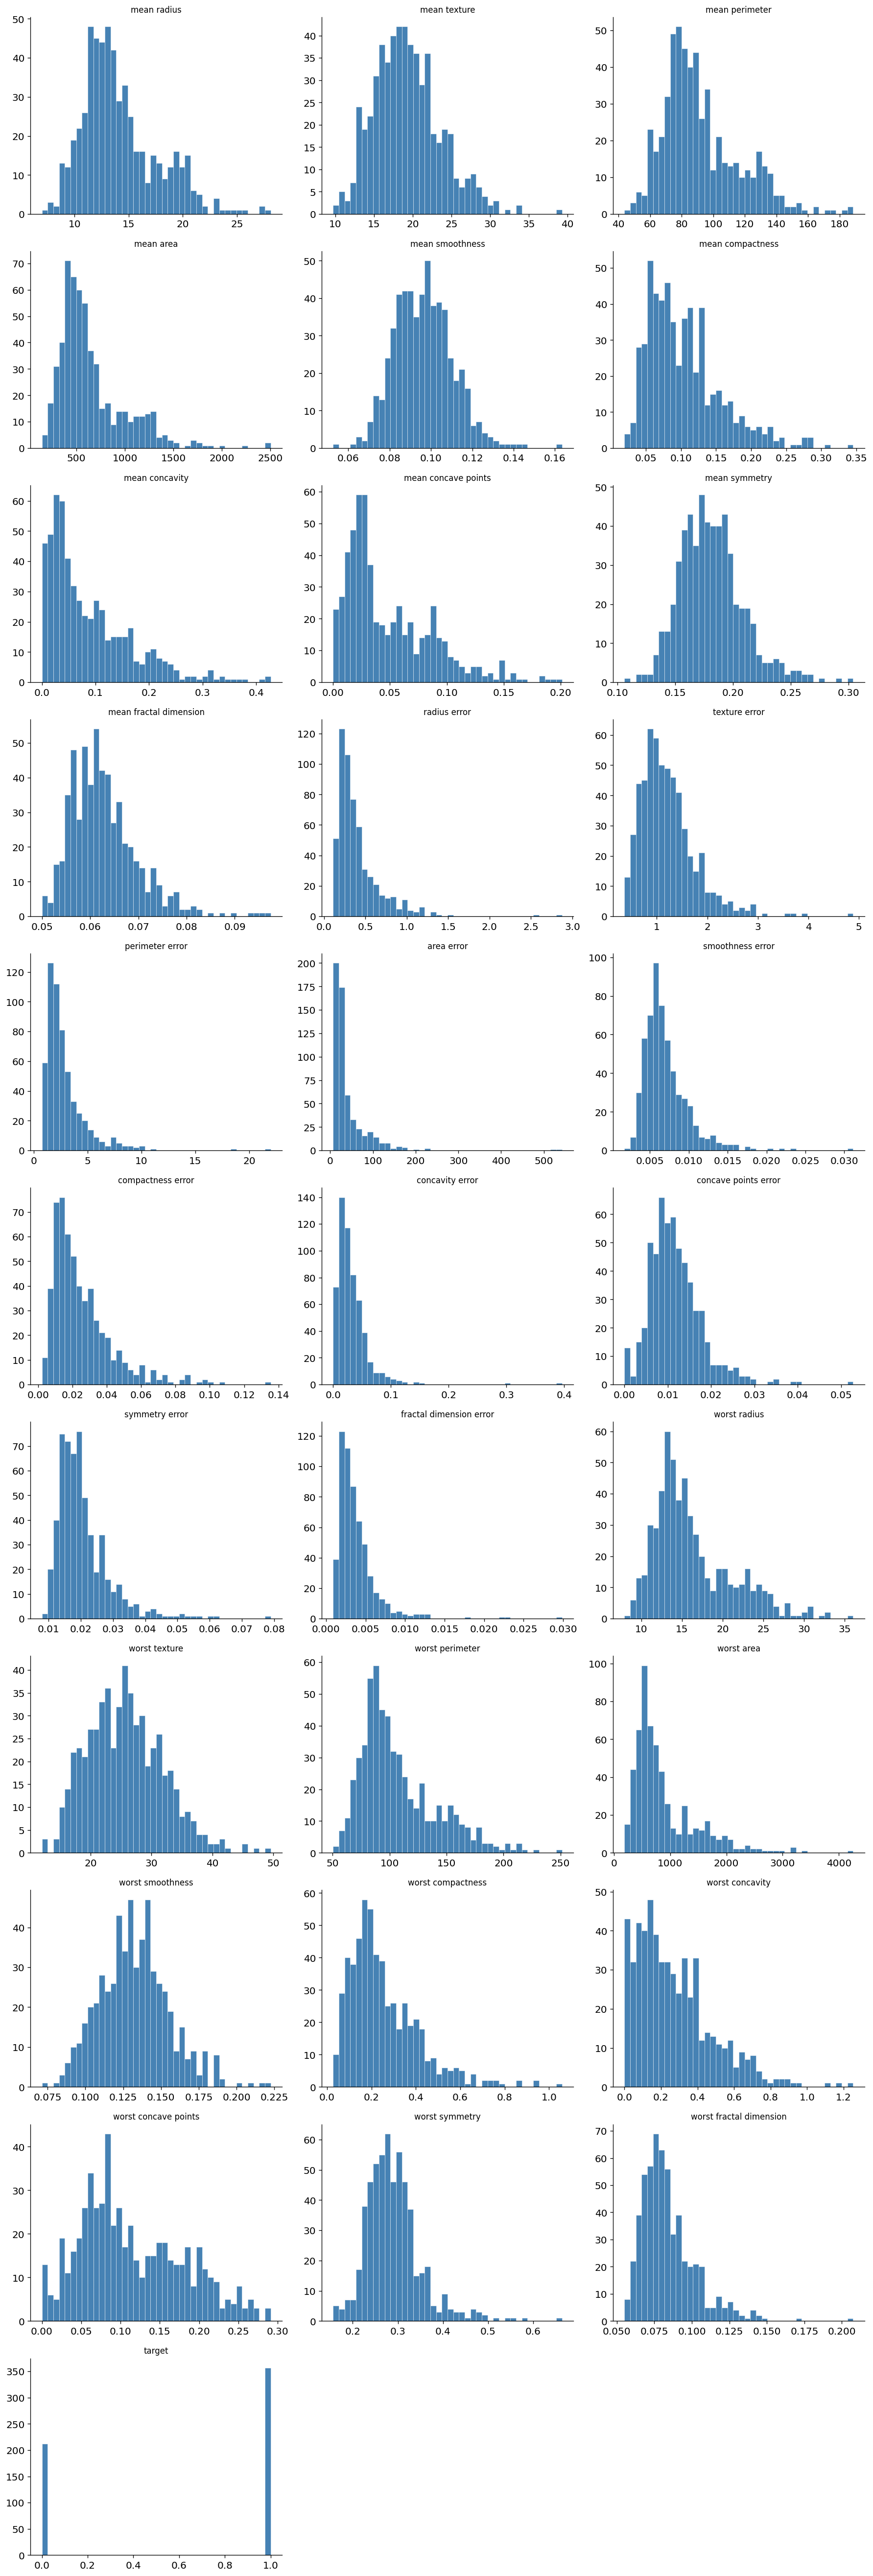

In [7]:
import matplotlib.pyplot as plt
import math

# Calculate how many rows you need for 3 columns per row
num_cols = len(df.columns)
cols_per_row = 3
num_rows = math.ceil(num_cols / cols_per_row)

# Create the figure with the dynamic grid
fig, axes = plt.subplots(num_rows, cols_per_row, figsize=(15, num_rows * 4))
axes = axes.flatten()

for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=40, color='steelblue', edgecolor='white', linewidth=0.3)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# Hide any extra empty subplots if the grid is larger than the number of columns
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [8]:
X = cancer_data.data   # shape (n, d)
y = cancer_data.target  # shape (n,)
print(cancer_data.target_names)
feature_names = cancer_data.feature_names

print(f'X shape : {X.shape}   ({X.shape[0]} samples, {X.shape[1]} features)')
print(f'y shape : {y.shape}')
print(f'Feature names: {feature_names}')
print(f'Target (Diagnosis) — min: {y.min():.2f},  max: {y.max():.2f},  mean: {y.mean():.2f}')

['malignant' 'benign']
X shape : (569, 30)   (569 samples, 30 features)
y shape : (569,)
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target (Diagnosis) — min: 0.00,  max: 1.00,  mean: 0.63


In [9]:
n = len(X)
n_train = int(0.8 * n)

# Shuffle indices first — order in the dataset may not be random!
idx = np.arange(n)
rng = np.random.default_rng(42)
rng.shuffle(idx)

train_idx = idx[:n_train]
test_idx  = idx[n_train:]

X_train_manual = X[train_idx]
y_train_manual = y[train_idx]
X_test_manual  = X[test_idx]
y_test_manual  = y[test_idx]

print(f'Total samples : {n}')
print(f'Train samples : {len(X_train_manual)}  ({100*len(X_train_manual)/n:.1f}%)')
print(f'Test  samples : {len(X_test_manual)}   ({100*len(X_test_manual)/n:.1f}%)')
print(f'\nTrain mean y  : {y_train_manual.mean():.4f}')
print(f'Test  mean y  : {y_test_manual.mean():.4f}   ← should be similar to train')

Total samples : 569
Train samples : 455  (80.0%)
Test  samples : 114   (20.0%)

Train mean y  : 0.6264
Test  mean y  : 0.6316   ← should be similar to train


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.20,    # 20% held out
    random_state = 42,      # reproducible shuffle
)

print(f'X_train : {X_train.shape}   y_train : {y_train.shape}')
print(f'X_test  : {X_test.shape}    y_test  : {y_test.shape}')

X_train : (455, 30)   y_train : (455,)
X_test  : (114, 30)    y_test  : (114,)


In [11]:
scaler = StandardScaler()

# Fit ONLY on training data — never on test!
scaler.fit(X_train)

# Transform both sets using the training statistics
X_train_scaled = scaler.transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Before scaling — MedInc column stats:')
print(f'  train mean={X_train[:,0].mean():.3f}, std={X_train[:,0].std():.3f}')

print('\nAfter scaling — MedInc column stats:')
print(f'  train mean={X_train_scaled[:,0].mean():.6f}  (≈ 0)')
print(f'  train std ={X_train_scaled[:,0].std():.6f}   (≈ 1)')
print(f'  test  mean={X_test_scaled[:,0].mean():.4f}   (close but not exactly 0 — that is OK)')

Before scaling — MedInc column stats:
  train mean=14.118, std=3.532

After scaling — MedInc column stats:
  train mean=-0.000000  (≈ 0)
  train std =1.000000   (≈ 1)
  test  mean=0.0136   (close but not exactly 0 — that is OK)


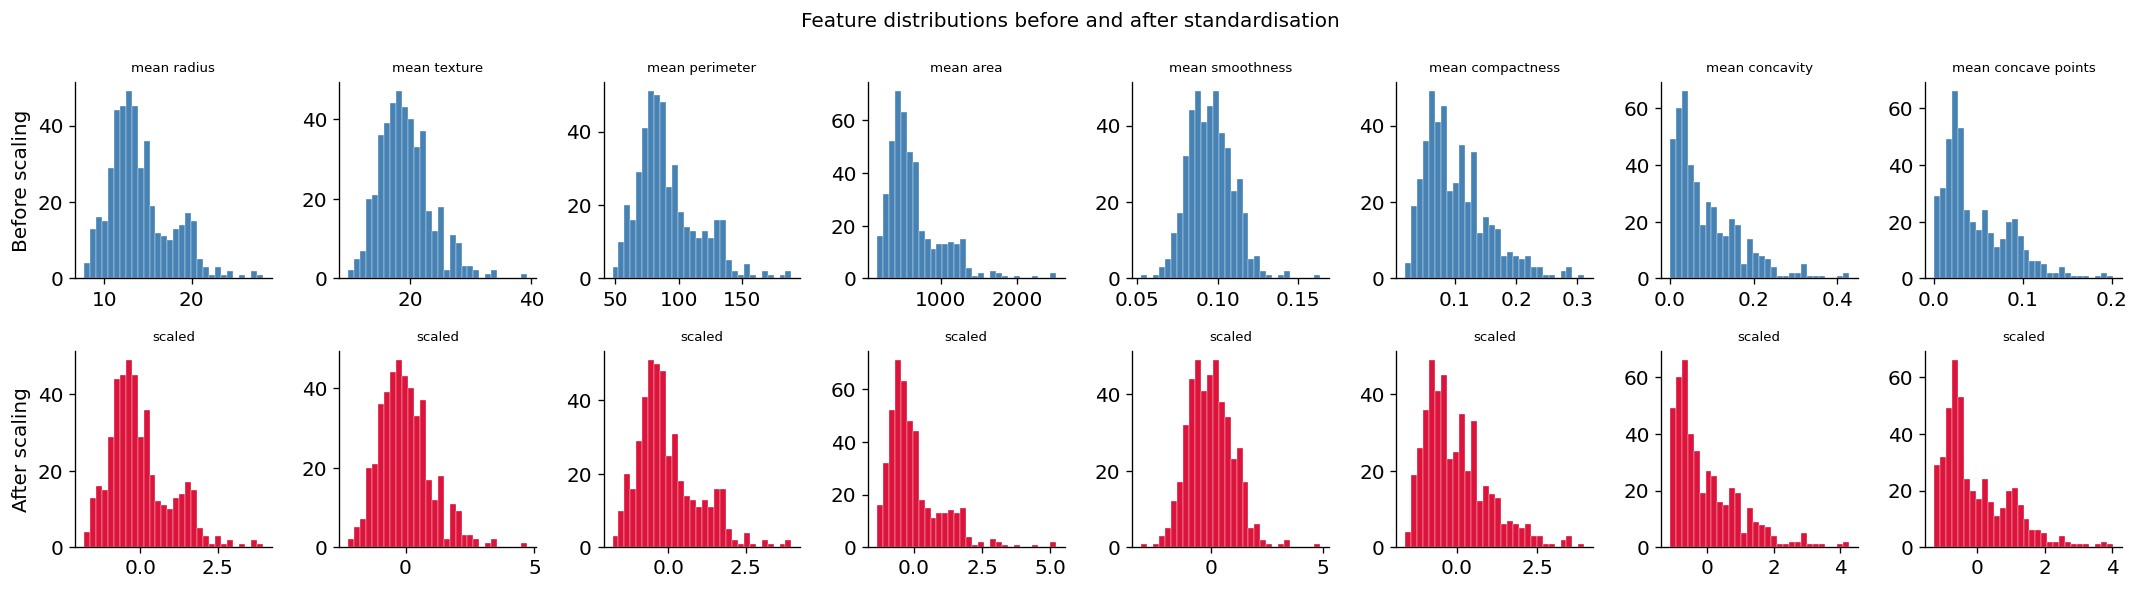

In [12]:
# Visualise: before vs after scaling for all 8 features
fig, axes = plt.subplots(2, 8, figsize=(18, 5))

for i in range(8):
    axes[0, i].hist(X_train[:, i],        bins=30, color='steelblue', edgecolor='w', lw=0.2)
    axes[1, i].hist(X_train_scaled[:, i], bins=30, color='crimson',   edgecolor='w', lw=0.2)
    axes[0, i].set_title(feature_names[i], fontsize=8)
    axes[1, i].set_title('scaled', fontsize=8)

axes[0, 0].set_ylabel('Before scaling')
axes[1, 0].set_ylabel('After scaling')
plt.suptitle('Feature distributions before and after standardisation', fontsize=12)
plt.tight_layout()
plt.show()

In [24]:
# Importing SVC (Support Vector Classifier) for training
from sklearn.svm import SVC

# Importing evaluation metrics
from sklearn.metrics import (accuracy_score, roc_auc_score,
                             confusion_matrix, classification_report,
                             ConfusionMatrixDisplay)

# For plotting
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# Creating a linear SVM model with C=1.0 (default regularization)
# probability=True allows us to get probability scores for ROC-AUC
model_linear = SVC(kernel='linear', C=1.0, probability=True, random_state=42)

# Training the model on scaled training data
model_linear.fit(X_train_scaled, y_train)
print("Model trained ✓")

Model trained ✓


In [26]:
# Predicting class labels for test data
y_pred = model_linear.predict(X_test_scaled)

# Predicting probabilities (needed for ROC-AUC score)
y_prob = model_linear.predict_proba(X_test_scaled)[:, 1]

# Printing accuracy and ROC-AUC score
print(f"Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC   : {roc_auc_score(y_test, y_prob):.4f}")

# Detailed report showing precision, recall, f1-score per class
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Malignant', 'Benign']))

Accuracy  : 0.9561
ROC-AUC   : 0.9964

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.93      0.95      0.94        43
      Benign       0.97      0.96      0.96        71

    accuracy                           0.96       114
   macro avg       0.95      0.96      0.95       114
weighted avg       0.96      0.96      0.96       114



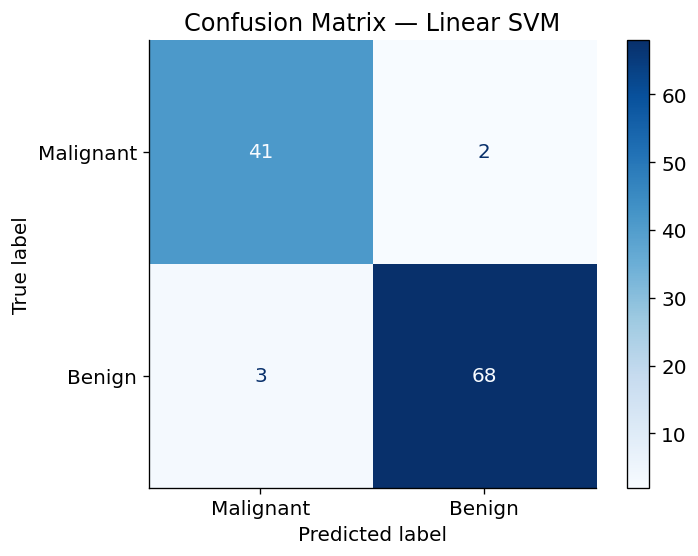

In [27]:
# Computing confusion matrix
# Shows: True Positives, True Negatives, False Positives, False Negatives
cm = confusion_matrix(y_test, y_pred)

# Plotting the confusion matrix as a heatmap
disp = ConfusionMatrixDisplay(cm, display_labels=['Malignant', 'Benign'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Linear SVM')
plt.tight_layout()
plt.show()

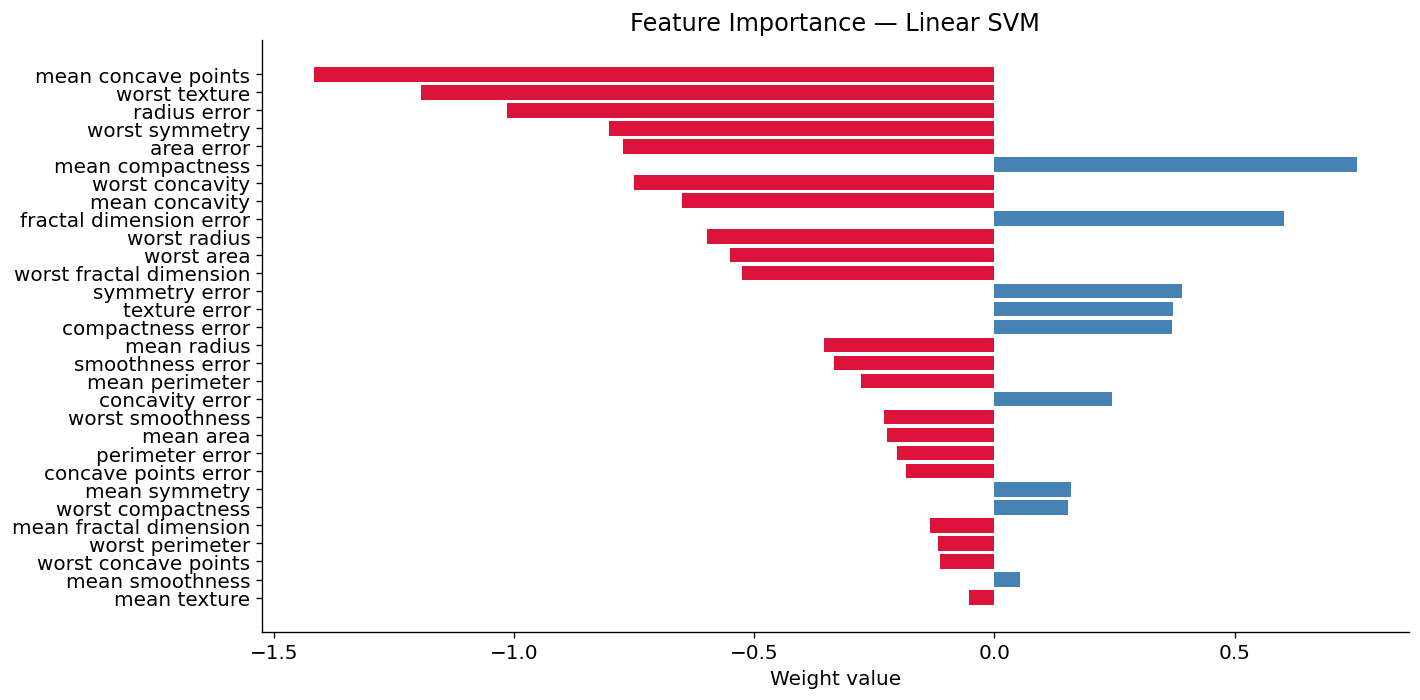

In [28]:
# coef_[0] gives the weight of each feature in the decision boundary
# Larger absolute weight = more important feature
weights = model_linear.coef_[0]
feature_names = load_breast_cancer().feature_names

# Sorting features by absolute weight value (most important first)
sorted_idx = np.argsort(np.abs(weights))[::-1]
sorted_weights = weights[sorted_idx]
sorted_names = feature_names[sorted_idx]

# Plotting horizontal bar chart
# Crimson = negative weight (pushes towards Malignant)
# Steelblue = positive weight (pushes towards Benign)
plt.figure(figsize=(12, 6))
colors = ['crimson' if w < 0 else 'steelblue' for w in sorted_weights]
plt.barh(sorted_names[::-1], sorted_weights[::-1], color=colors[::-1])
plt.xlabel('Weight value')
plt.title('Feature Importance — Linear SVM')
plt.tight_layout()
plt.show()

In [29]:
# Printing top 5 features that most influence the decision boundary
print("Top 5 most important features:")
for i in range(5):
    print(f"  {sorted_names[i]:<35} weight = {sorted_weights[i]:.4f}")

# Support vectors are the data points closest to the decision boundary
# These are the points that actually define where the boundary is
print(f"\nSupport vectors per class : {model_linear.n_support_}")
print(f"Total support vectors     : {sum(model_linear.n_support_)}")

Top 5 most important features:
  mean concave points                 weight = -1.4162
  worst texture                       weight = -1.1933
  radius error                        weight = -1.0140
  worst symmetry                      weight = -0.8027
  area error                          weight = -0.7742

Support vectors per class : [16 20]
Total support vectors     : 36


## Geometric Interpretation

The features with the largest absolute weights contribute most to the SVM decision boundary.
A large positive weight pushes prediction towards Benign (1), while a large negative weight
pushes towards Malignant (0). These features define the orientation of the separating 
hyperplane in 30-dimensional feature space.
